# 🔌 EDA aplicado a la gestión energética

## Caso de estudio: ¿dónde están las oportunidades de ahorro de una instalación?

Una empresa entrega **90 días de mediciones horarias** de su consumo eléctrico. Como analistas, debemos responder:

1. ¿Podemos confiar en estos datos?
2. ¿Cuándo consume más energía la instalación?
3. ¿Cuál es su demanda máxima, factor de carga e intensidad energética?
4. ¿Existen picos o consumos anómalos que no deberían estar ahí?
5. ¿Qué acción de eficiencia energética debería investigarse primero?

> **Hilo conductor:** calidad de los datos → patrones → indicadores → anomalías → oportunidad de ahorro → decisión.

> 🤖 Durante la clase veremos en vivo cómo **GitHub Copilot** apoya el análisis: haremos preguntas concretas y evaluaremos juntos sus respuestas.


## Resultados de aprendizaje

Al finalizar esta clase podrás:

- Explicar qué es un **EDA** y por qué es el primer paso de cualquier proyecto de datos.
- Explicar por qué los datos reales casi nunca llegan limpios.
- Leer gráficos y tablas típicas de un EDA (perfiles de carga, mapas de calor, correlaciones, boxplots) sin programarlos desde cero.
- Reconocer indicadores clave de gestión energética y qué significan para el negocio.
- Formular buenas preguntas a Copilot y **validar críticamente** sus respuestas.
- Comunicar una conclusión separando hechos, hipótesis y recomendaciones.

> No memorices sintaxis. Entiende el razonamiento, para poder reproducirlo apoyándote en la IA.


## ¿Por qué los datos casi nunca son perfectos?

En el mundo real, **los datos siempre traen algún grado de error**. El EDA existe para descubrirlos antes de que contaminen una decisión de negocio.

Causas típicas:

- **Fallas de sensores:** descalibración, desconexión, valores absurdos (una temperatura de 300 °C).
- **Errores humanos de digitación:** "operando", "Operando " y "OPERANDO" son la misma idea para una persona, pero tres categorías distintas para el computador.
- **Duplicados** por fallas del sistema que carga los datos.
- **Valores imposibles:** energía negativa, temperaturas fuera de rango físico.
- **Eventos reales no documentados** (feriados, mantenimientos) que parecen errores, pero no lo son.

Calcular indicadores sin auditar la calidad primero puede llevar a decisiones costosas basadas en un simple error de digitación. **El EDA es un control de calidad, no un formalismo académico.**

> En esta clase fabricaremos errores a propósito, para practicar cómo detectarlos y decidir qué hacer con ellos.


## 0. Preparación

No usaremos datos externos: los generaremos dentro del notebook, de forma aleatoria pero realista. Así no dependemos de internet y podemos "ensuciar" el dato a propósito para practicar la auditoría de calidad.

La siguiente celda importa `numpy`, `pandas`, `matplotlib` y `seaborn` (ya conocidas de clases anteriores) y define opciones de presentación.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

# 1. Construir el caso de estudio

Esta tabla simula lo que entregaría el área de mantenimiento de la empresa. **Cada fila es una hora** de operación durante 90 días (90 × 24 = 2,160 filas). Estas son las columnas que vas a ver, qué significa cada una y en qué unidad viene:

| Columna | Qué significa | Unidad |
|---|---|---|
| `fecha_hora` | Marca de tiempo de la medición (una por hora). | fecha y hora |
| `energia_kwh` | Cuánta electricidad se **consumió** durante esa hora. | kWh (kilovatios-hora) |
| `demanda_kw` | Con qué **intensidad** se usó la electricidad en ese momento (no es lo mismo que la energía). | kW (kilovatios) |
| `temperatura_c` | Temperatura ambiente en el momento de la medición; afecta aire acondicionado o calefacción. | °C |
| `produccion_unidades` | Unidades fabricadas esa hora (0 si la planta no estaba operando). | unidades |
| `ocupacion` | Número aproximado de personas en el lugar esa hora. | personas |
| `tarifa` | Periodo tarifario de esa hora: **Punta** (más cara), **Media** o **Valle** (más económica). | categoría |
| `estado_equipo` | Si el equipo estaba **Operando** o **En espera** esa hora. | categoría |

> 💡 **Energía vs. demanda:** la energía (kWh) es como el "agua que salió de la llave" en una hora; la demanda (kW) es "qué tan abierta estaba la llave" en ese instante. Dos horas pueden consumir la misma energía total con demandas muy distintas.

El consumo simulado depende de la producción y del clima. **No necesitas entender la fórmula**; lo importante es el resultado: una tabla horaria, tal como la recibirías de un cliente real.


In [2]:
fechas = pd.date_range("2026-01-01", periods=90*24, freq="h")
df_base = pd.DataFrame({"fecha_hora": fechas})
df_base["hora"] = df_base["fecha_hora"].dt.hour
df_base["dia_num"] = df_base["fecha_hora"].dt.dayofweek
es_laboral = df_base["dia_num"] < 5
en_operacion = es_laboral & df_base["hora"].between(7, 18)

df_base["temperatura_c"] = 18 + 5*np.sin(2*np.pi*(df_base["hora"]-8)/24) + np.random.normal(0,1.5,len(df_base))
df_base["produccion_unidades"] = np.clip(np.where(en_operacion, np.random.normal(80,15,len(df_base)),0),0,None).round()
df_base["ocupacion"] = np.where(en_operacion, np.random.randint(35,81,len(df_base)), np.random.randint(0,6,len(df_base)))

df_base["energia_kwh"] = np.clip(
    22 + 0.38*df_base["produccion_unidades"]
    + 1.8*np.maximum(df_base["temperatura_c"]-20,0)
    + np.random.normal(0,3,len(df_base)), 5, None)
df_base["demanda_kw"] = df_base["energia_kwh"]*np.random.uniform(0.92,1.12,len(df_base))
df_base["tarifa"] = np.select([df_base["hora"].between(18,21),df_base["hora"].between(7,17)], ["Punta","Media"], default="Valle")
df_base["estado_equipo"] = np.where(en_operacion,"Operando","En espera")

df_base = df_base[["fecha_hora","energia_kwh","demanda_kw","temperatura_c","produccion_unidades","ocupacion","tarifa","estado_equipo"]]
df_base.head()

,fecha_hora,energia_kwh,demanda_kw,temperatura_c,produccion_unidades,ocupacion,tarifa,estado_equipo
0,2026-01-01 00:00:00,22.37,22.68,14.41,0.00,5,Valle,En espera
1,2026-01-01 01:00:00,19.93,19.18,12.96,0.00,2,Valle,En espera
2,2026-01-01 02:00:00,17.97,18.46,13.97,0.00,4,Valle,En espera
3,2026-01-01 03:00:00,19.45,21.62,15.45,0.00,0,Valle,En espera
4,2026-01-01 04:00:00,20.49,21.26,13.32,0.00,5,Valle,En espera


## 1.1 Agregar problemas deliberados

En la vida real nunca fabricamos errores; ya vienen incluidos en los datos que nos entregan. Aquí, solo por práctica, introduciremos a propósito los problemas más comunes:

| Problema | Causa típica |
|---|---|
| Valores **faltantes** (`NaN`) | Un sensor se desconecta o una casilla queda vacía. |
| **Negativos imposibles** (energía < 0) | Error de calibración o de digitación. |
| **Fuera de rango físico** (85 °C) | Falla de sensor o error de unidades. |
| Texto **inconsistente** (`"operando "`) | Digitación manual sin estandarizar. |
| **Filas duplicadas** | Error del sistema que carga los datos. |

La tarea será encontrar cada uno de estos problemas y decidir, con criterio de negocio, qué hacer con cada uno.


In [3]:
df_sucio = df_base.copy()
idx = np.random.choice(df_sucio.index,28,replace=False)
df_sucio.loc[idx[:12],"energia_kwh"] = np.nan
df_sucio.loc[idx[12:20],"temperatura_c"] = np.nan
df_sucio.loc[idx[20:],"estado_equipo"] = np.nan
df_sucio.loc[np.random.choice(df_sucio.index,3,replace=False),"energia_kwh"] = -15
df_sucio.loc[np.random.choice(df_sucio.index,2,replace=False),"temperatura_c"] = 85
idx_picos = np.random.choice(df_sucio.index,6,replace=False)
df_sucio.loc[idx_picos,["energia_kwh","demanda_kw"]] *= 3.5
df_sucio.loc[np.random.choice(df_sucio.index,8,replace=False),"estado_equipo"] = "operando "
df_sucio = pd.concat([df_sucio,df_sucio.sample(5,random_state=10)],ignore_index=True)
print(f"Registros recibidos: {len(df_sucio):,}")

Registros recibidos: 2,165


# 2. Inspección inicial

Antes de calcular promedios, hay que **mirar la tabla cruda** y confirmar lo básico:

- ¿Cuántas filas y columnas tiene?
- ¿Qué periodo cubre realmente? (a veces "dice" 90 días pero faltan semanas)
- ¿Qué tipo de dato tiene cada columna?
- ¿Qué representa cada fila? (aquí, una hora de operación, no un día)

Un resultado numéricamente correcto puede ser **conceptualmente falso** si se interpreta mal la estructura de la tabla.


In [4]:
display(df_sucio.head())
print("Dimensiones:",df_sucio.shape)
print("Periodo:",df_sucio.fecha_hora.min(),"a",df_sucio.fecha_hora.max())
df_sucio.info()

,fecha_hora,energia_kwh,demanda_kw,temperatura_c,produccion_unidades,ocupacion,tarifa,estado_equipo
0,2026-01-01 00:00:00,22.37,22.68,14.41,0.00,5,Valle,En espera
1,2026-01-01 01:00:00,19.93,19.18,12.96,0.00,2,Valle,En espera
2,2026-01-01 02:00:00,17.97,18.46,13.97,0.00,4,Valle,En espera
3,2026-01-01 03:00:00,19.45,21.62,15.45,0.00,0,Valle,En espera
4,2026-01-01 04:00:00,20.49,21.26,13.32,0.00,5,Valle,En espera


Dimensiones: (2165, 8)
Periodo: 2026-01-01 00:00:00 a 2026-03-31 23:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2165 entries, 0 to 2164
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   fecha_hora           2165 non-null   datetime64[ns]
 1   energia_kwh          2153 non-null   float64       
 2   demanda_kw           2165 non-null   float64       
 3   temperatura_c        2157 non-null   float64       
 4   produccion_unidades  2165 non-null   float64       
 5   ocupacion            2165 non-null   int32         
 6   tarifa               2165 non-null   object        
 7   estado_equipo        2156 non-null   object        
dtypes: datetime64[ns](1), float64(4), int32(1), object(2)
memory usage: 127.0+ KB


### 🤖 GitHub Copilot en acción — Ver el dato crudo (y que los huecos se noten)

En Excel, para "ver" 2,000 filas necesitarías desplazarte muchísimo o construir un gráfico dinámico. Un simple gráfico de líneas puede esconder los huecos si son pocos puntos entre miles; pidámosle a Copilot que nos ayude a que se noten:

> "Tengo un DataFrame `df_sucio` con una columna `fecha_hora` (una medición por hora) y una columna `energia_kwh` que tiene algunos valores `NaN`. Escríbeme código en Python que grafique la serie de tiempo completa de `energia_kwh` y que además resalte claramente, con líneas verticales o marcadores rojos, los puntos exactos donde el valor es `NaN`, para que los huecos se vean aunque sean pocos."

Pegamos el código sugerido en la celda siguiente y lo ejecutamos en vivo: ¿ahora sí se ven los huecos, el valor negativo y el pico?


In [50]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


# 3. Auditoría de calidad de los datos

Un EDA revisa cuatro dimensiones, válidas para cualquier tipo de dato:

- **Completitud:** ¿faltan mediciones?
- **Unicidad:** ¿hay registros o fechas duplicadas?
- **Validez:** ¿los valores son físicamente posibles?
- **Consistencia:** ¿las categorías de texto están escritas igual? ("Operando" vs. "operando ")

Un solo valor extremo mal capturado puede inflar la "demanda máxima" reportada y llevar a decisiones de inversión equivocadas (por ejemplo, sobredimensionar un transformador).


In [5]:
calidad = pd.DataFrame({
    "faltantes":df_sucio.isna().sum(),
    "faltantes_pct":df_sucio.isna().mean()*100,
    "unicos":df_sucio.nunique(dropna=False)
})
display(calidad)
print("Duplicados completos:",df_sucio.duplicated().sum())
print("Fechas repetidas:",df_sucio.duplicated("fecha_hora").sum())

,faltantes,faltantes_pct,unicos
fecha_hora,0,0.00,2160
energia_kwh,12,0.55,2147
demanda_kw,0,0.00,2160
temperatura_c,8,0.37,2152
produccion_unidades,0,0.00,79
ocupacion,0,0.00,52
tarifa,0,0.00,3
estado_equipo,9,0.42,4


Duplicados completos: 5
Fechas repetidas: 5


### 🤖 GitHub Copilot en acción — Visualizar los datos faltantes

La tabla anterior ya nos dice *cuántos* datos faltan por columna, pero no *dónde* se concentran. Pidámosle a Copilot que nos ayude a verlo en vivo:


> "Tengo un DataFrame `df_sucio` con una columna `fecha_hora` y una tabla `calidad` que ya tiene el porcentaje de faltantes por columna en `calidad['faltantes_pct']`. Escríbeme código en Python que dibuje: 1) un mapa de calor con seaborn que muestre dónde están los datos faltantes a lo largo del tiempo, usando `fecha_hora` como eje, y 2) un gráfico de barras horizontales con el porcentaje de faltantes por columna."

Pegamos el código sugerido en la celda siguiente y lo ejecutamos en vivo: ¿los faltantes están dispersos al azar o agrupados en algún periodo?

In [46]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


In [9]:
reglas = pd.Series({
    "energía negativa":(df_sucio.energia_kwh<0).sum(),
    "demanda negativa":(df_sucio.demanda_kw<0).sum(),
    "temperatura fuera de -10 a 45 °C":((df_sucio.temperatura_c<-10)|(df_sucio.temperatura_c>45)).sum(),
    "producción negativa":(df_sucio.produccion_unidades<0).sum()
})
display(reglas.to_frame("casos"))
display(df_sucio.estado_equipo.value_counts(dropna=False).to_frame("registros"))

,casos
energía negativa,3
demanda negativa,0
temperatura fuera de -10 a 45 °C,2
producción negativa,0


,registros
estado_equipo,
En espera,1383
Operando,765
NaN,9
operando,8


### 🤖 GitHub Copilot en acción — Ver los valores extremos con un boxplot

Ya vimos las reglas de validez en números. Ahora pidámosle a Copilot que nos ayude a verlos con un **boxplot** (diagrama de caja), donde los puntos sueltos por fuera de los "bigotes" son valores que se alejan mucho del resto:


> "Tengo un DataFrame `df_sucio` con las columnas `energia_kwh`, `demanda_kw` y `temperatura_c`. Escríbeme código en Python que dibuje tres boxplots lado a lado, uno por columna, usando seaborn y matplotlib, para detectar visualmente los valores atípicos."

Ejecutamos el resultado en vivo: ¿ves puntos muy separados de la caja en alguna de las tres variables?

In [47]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


### 🤖 GitHub Copilot en acción — Un problema de calidad que no vimos

Todavía no revisamos si faltan **horas completas** en la serie (por ejemplo, que el medidor se haya apagado y esas filas ni siquiera existan). Preguntemos en vivo:

> "Tengo un DataFrame `df_sucio` con una columna `fecha_hora` que debería tener una medición por hora, sin huecos, entre el primer y el último valor. Escríbeme código en Python que me diga cuántas horas faltan y me muestre las primeras 10."

Pegamos el código sugerido en la celda siguiente y lo ejecutamos en vivo: ¿encontró huecos? ¿el resultado tiene sentido?


In [ ]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


# 4. Limpieza reproducible y justificada

Regla de oro: **nunca modifiques el archivo original**; trabaja sobre una copia y **documenta cada decisión**. En la celda siguiente:

- **Duplicados:** se eliminan, quedándonos con el primer registro.
- **Texto inconsistente:** se estandariza a un formato único.
- **Valores imposibles:** se convierten en "dato faltante" (no se inventa un valor).
- **Huecos cortos:** se interpolan en el tiempo (máximo 3 horas seguidas). Los huecos largos quedan como faltantes.
- **Categorías faltantes:** se marcan como `"Sin registro"`.

> No eliminamos los picos solo por ser altos: pueden ser eventos reales (una máquina grande arrancando). Eso se investiga más adelante, en anomalías.


In [31]:
df = df_sucio.sort_values("fecha_hora").drop_duplicates("fecha_hora", keep="first")
df = df.set_index("fecha_hora")
print("Paso 1 - Duplicados eliminados. Registros:", len(df))

df["estado_equipo"] = df["estado_equipo"].astype("string").str.strip().str.title()
df["tarifa"] = df["tarifa"].astype("string").str.strip().str.title()
print("Paso 2 - Texto estandarizado (mayúsculas y espacios).")

df.loc[df["energia_kwh"] < 0, "energia_kwh"] = np.nan
df.loc[~df["temperatura_c"].between(-10, 45), "temperatura_c"] = np.nan
print("Paso 3 - Valores imposibles convertidos en faltantes.")

df["energia_kwh"] = df["energia_kwh"].interpolate(method="time", limit=3)
df["temperatura_c"] = df["temperatura_c"].interpolate(method="time", limit=3)
df["estado_equipo"] = df["estado_equipo"].fillna("Sin registro")
print("Paso 4 - Huecos cortos rellenados (máximo 3 horas).")

print("\nRegistros finales:", len(df))
display(df.isna().sum().to_frame("faltantes restantes"))

Paso 1 - Duplicados eliminados. Registros: 2160
Paso 2 - Texto estandarizado (mayúsculas y espacios).
Paso 3 - Valores imposibles convertidos en faltantes.
Paso 4 - Huecos cortos rellenados (máximo 3 horas).

Registros finales: 2160


,faltantes restantes
energia_kwh,0
demanda_kw,0
temperatura_c,0
produccion_unidades,0
ocupacion,0
tarifa,0
estado_equipo,0


### Comprobar visualmente que la limpieza funcionó

No basta con confiar en que el código "debió funcionar". Comparemos la serie **antes** (cruda, con huecos y el pico multiplicado por 3.5) contra la serie **después** de la limpieza, en una misma gráfica. Si la limpieza fue razonable, la línea "después" debería verse suave y sin los huecos ni el valor negativo, conservando el resto del comportamiento real.


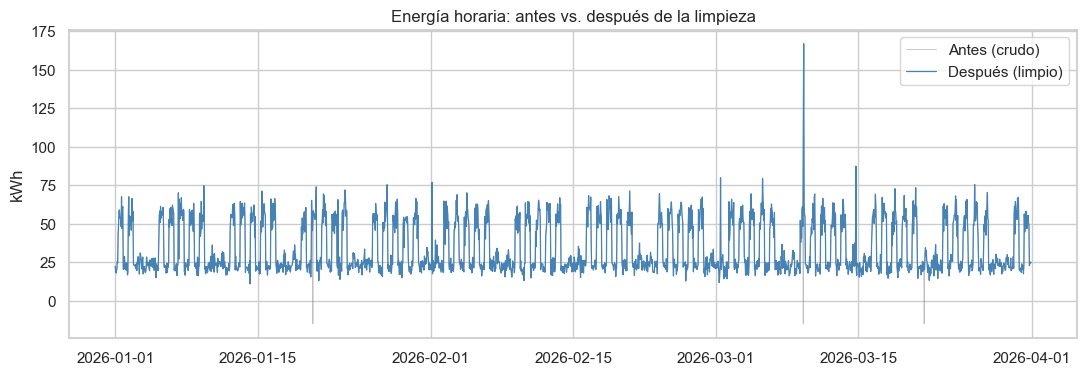

In [32]:
crudo = df_sucio.sort_values("fecha_hora").set_index("fecha_hora")

plt.figure(figsize=(13,4))
plt.plot(crudo.energia_kwh, lw=.6, alpha=.5, color="gray", label="Antes (crudo)")
plt.plot(df.energia_kwh, lw=.9, color="steelblue", label="Después (limpio)")
plt.title("Energía horaria: antes vs. después de la limpieza")
plt.ylabel("kWh"); plt.legend(); plt.show()


## ¿Por qué no simplemente rellenar todo con el promedio?

Rellenar con la media puede **borrar patrones horarios reales**, **reducir la variabilidad** artificialmente y **ocultar picos** que caían justo en el hueco. La técnica de relleno debe ajustarse al proceso físico y a la duración del hueco: interpolar en el tiempo para huecos cortos, y dejar como faltante los huecos largos (decirlo explícitamente en el informe).


# 5. Convertir el tiempo en información operacional

Una fecha en bruto no dice mucho por sí sola. Al descomponerla en **hora del día**, **día de la semana** y **si es horario laboral**, podemos comparar momentos similares entre sí: un lunes 2 p.m. no es lo mismo que un sábado 2 p.m., y mezclarlos en un solo promedio escondería información valiosa.


In [33]:
df["hora"] = df.index.hour
df["dia_num"] = df.index.dayofweek
df["dia_semana"] = df.dia_num.map({0:"Lunes",1:"Martes",2:"Miércoles",3:"Jueves",4:"Viernes",5:"Sábado",6:"Domingo"})
df["mes"] = df.index.month
df["es_laboral"] = df.dia_num<5
df["en_horario"] = df.es_laboral & df.hora.between(7,18)
df.head()

,energia_kwh,demanda_kw,temperatura_c,produccion_unidades,ocupacion,tarifa,estado_equipo,hora,dia_num,dia_semana,mes,es_laboral,en_horario
fecha_hora,,,,,,,,,,,,,
2026-01-01 00:00:00,22.37,22.68,14.41,0.00,5,Valle,En Espera,0,3,Jueves,1,True,False
2026-01-01 01:00:00,19.93,19.18,12.96,0.00,2,Valle,En Espera,1,3,Jueves,1,True,False
2026-01-01 02:00:00,17.97,18.46,13.97,0.00,4,Valle,En Espera,2,3,Jueves,1,True,False
2026-01-01 03:00:00,19.45,21.62,15.45,0.00,0,Valle,En Espera,3,3,Jueves,1,True,False
2026-01-01 04:00:00,20.49,21.26,13.32,0.00,5,Valle,En Espera,4,3,Jueves,1,True,False


# 6. ¿Cuándo consume energía la instalación?

El **perfil horario** muestra a qué horas el consumo es alto o bajo, y si existe una carga base que nunca desaparece. Usamos tres métricas:

- **Media:** idea general, sensible a valores extremos.
- **Mediana:** el valor "típico".
- **P95:** casi nunca se supera; clave para entender los **picos** que definen la demanda máxima y buena parte de la factura.

El gráfico resalta en verde el horario laboral, para comparar visualmente.


,media,mediana,p95
hora,,,
0,21.58,21.50,26.33
1,21.90,22.27,26.45
2,21.73,21.42,27.93
3,23.43,22.73,27.91
4,21.81,21.79,26.17
5,22.79,22.36,26.50
6,22.03,22.16,26.87
7,43.35,48.55,64.54
8,42.57,48.40,61.34


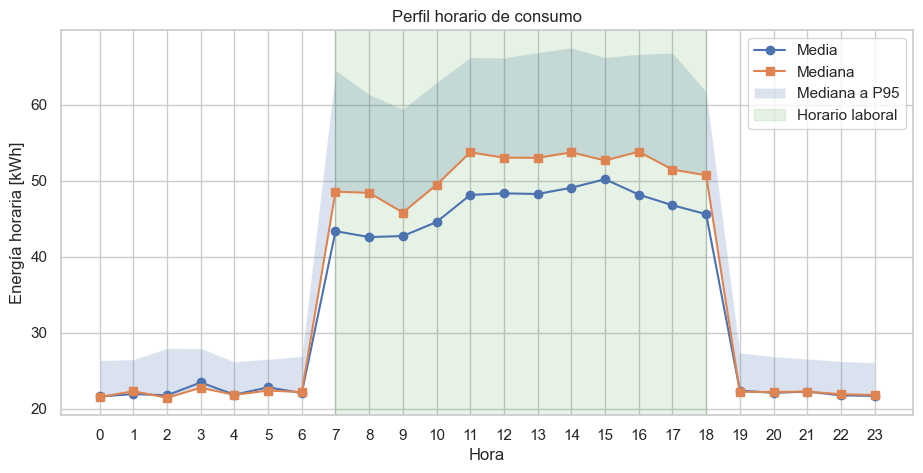

In [34]:
perfil = df.groupby("hora").energia_kwh.agg(
    media="mean", mediana="median", p95=lambda x:x.quantile(.95))
display(perfil)

plt.figure(figsize=(11,5))
plt.plot(perfil.index,perfil.media,marker="o",label="Media")
plt.plot(perfil.index,perfil.mediana,marker="s",label="Mediana")
plt.fill_between(perfil.index,perfil.mediana,perfil.p95,alpha=.2,label="Mediana a P95")
plt.axvspan(7,18,color="green",alpha=.1,label="Horario laboral")
plt.title("Perfil horario de consumo")
plt.xlabel("Hora"); plt.ylabel("Energía horaria [kWh]"); plt.xticks(range(24)); plt.legend(); plt.show()

## Interpretación guiada del perfil horario

Observa el gráfico anterior y responde estas preguntas con tus propias palabras (no hay una única respuesta correcta, lo importante es justificar con lo que ves):

1. ¿A qué hora parece iniciar la operación de la instalación?
2. ¿La carga cae de forma clara después del horario de cierre, o se mantiene alta?
3. ¿La carga base nocturna (la línea que nunca baja de cierto nivel) te parece razonable o es sospechosamente alta?
4. ¿La zona sombreada entre la mediana y el P95 es angosta (consumo muy estable) o ancha (consumo con picos frecuentes)?
5. ¿El momento de mayor consumo coincide con un periodo tarifario costoso (Punta)? Si es así, ¿por qué eso le importa a la gerencia financiera?


# 7. Mapa de calor semanal: hora × día

El gráfico anterior mezclaba todos los días de la semana en una sola línea por hora. Ahora vamos a **separar por día de la semana también**, usando un mapa de calor: cada celda del mapa representa el consumo promedio de una combinación específica de día y hora (por ejemplo, "martes a las 3 p.m.").

Esta vista es muy útil para detectar **operación fuera de lo programado**: por ejemplo, si un sábado a medianoche aparece un color tan intenso como un martes a mediodía, eso merece una pregunta a mantenimiento.


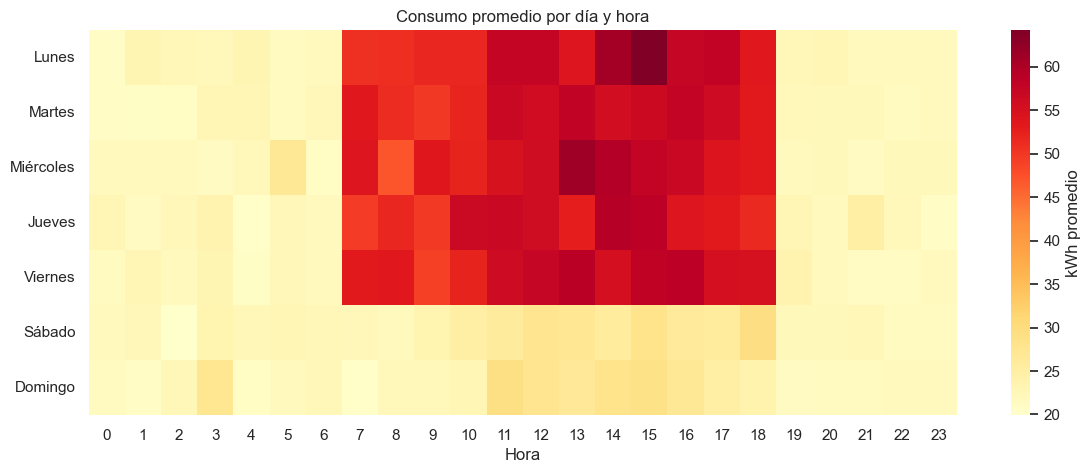

In [35]:
orden=["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
mapa=df.pivot_table(index="dia_semana",columns="hora",values="energia_kwh",aggfunc="mean").reindex(orden)
plt.figure(figsize=(14,5))
sns.heatmap(mapa,cmap="YlOrRd",cbar_kws={"label":"kWh promedio"})
plt.title("Consumo promedio por día y hora"); plt.xlabel("Hora"); plt.ylabel(""); plt.show()

# 8. Indicadores de desempeño energético (KPI)

## Factor de carga

$$
FC=\frac{P_{promedio}}{P_{máxima}}
$$

Compara el consumo promedio contra el pico más alto. Cerca de **1**: uso uniforme (eficiente). Cerca de **0**: picos altos que suelen **encarecer la factura**.

## Intensidad energética

$$
IE=\frac{Energía\ consumida}{Producción}
$$

Cuánta energía se gasta por unidad producida. Permite distinguir entre dos casos que parecen iguales:

- La instalación **se volvió más eficiente**. ✅
- La instalación simplemente **produjo menos**. ⚠️ No es una mejora real.


### 🤖 GitHub Copilot en acción — Calcular los KPI

Ya tenemos los conceptos claros (factor de carga e intensidad energética). Ahora, en lugar de escribir el código nosotros, pidámosle a Copilot que lo traduzca:

> "Tengo un DataFrame `df` con las columnas `energia_kwh` (kWh), `demanda_kw` (kW) y `produccion_unidades`. Necesito calcular estos indicadores y guardarlos en variables con estos nombres exactos: `energia_total` (suma de energia_kwh), `demanda_max` (máximo de demanda_kw), `demanda_media` (promedio de demanda_kw), `factor_carga` (demanda_media dividido demanda_max), `produccion_total` (suma de produccion_unidades) e `intensidad` (energia_total dividido produccion_total). Muéstrame el resultado en una tabla ordenada con pandas."

Pegamos el código sugerido en la celda siguiente y lo ejecutamos en vivo: ¿los nombres de las variables coinciden con los que pedimos? Los necesitaremos más adelante en la clase.


In [51]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


### 🤖 GitHub Copilot en acción — Un vistazo rápido al factor de carga

Un número como "0.62" es abstracto. Pidámosle a Copilot que lo convierta en algo visual:


> "Tengo una variable `factor_carga`, un número entre 0 y 1. Escríbeme código en Python con matplotlib que dibuje una barra horizontal tipo medidor mostrando ese valor en una escala de 0 a 1, con líneas de referencia en 0.25, 0.5, 0.75 y 1, y el valor numérico junto a la barra."

Ejecutamos el resultado en vivo: ¿la barra se interpreta más rápido que el número solo?

In [48]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


> **Discusión en clase:** si el consumo total baja 10 % pero la producción baja 20 %, la intensidad energética en realidad **aumenta**. La instalación consume menos en términos absolutos, pero es *menos eficiente* por cada unidad que produce. Esta es una de las trampas más comunes al leer reportes de energía sin mirar el contexto de producción.


# 9. ¿Qué variables acompañan el consumo?

La **correlación de Pearson** resume, entre -1 y 1, qué tan fuerte se relacionan dos variables:

- Cerca de **+1**: suben juntas. Cerca de **-1**: una sube y la otra baja. Cerca de **0**: sin relación lineal clara.

### ⚠️ Correlación no es causalidad

Que dos variables se muevan juntas no prueba que una cause la otra. Sirve para **generar hipótesis**, no para cerrar conclusiones.


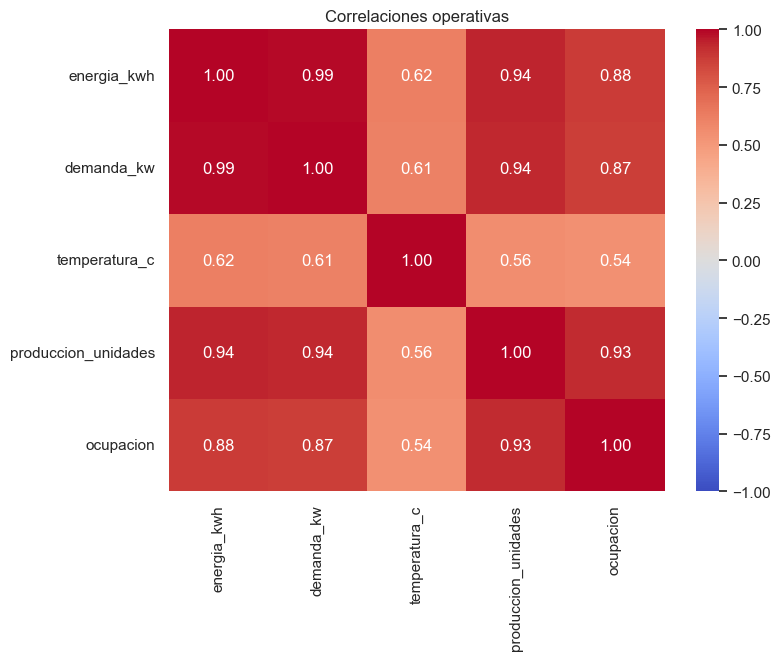

In [38]:
vars_num=["energia_kwh","demanda_kw","temperatura_c","produccion_unidades","ocupacion"]
corr=df[vars_num].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1)
plt.title("Correlaciones operativas"); plt.show()

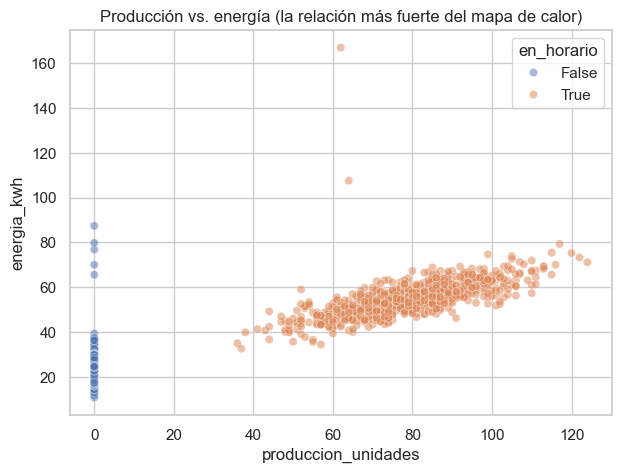

In [39]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,x="produccion_unidades",y="energia_kwh",hue="en_horario",alpha=.5)
plt.title("Producción vs. energía (la relación más fuerte del mapa de calor)")
plt.show()

# 10. Detección contextual de anomalías

Una **anomalía** es un valor que se sale mucho de lo normal. Ojo: no es lo mismo que un error. Puede ser una falla real, un evento extraordinario (una máquina grande arrancando), o hasta una **oportunidad de ahorro** que vale la pena mirar de cerca.

## ¿Cómo decidimos qué es "mucho"?

Usamos una regla estadística simple, el **rango intercuartílico (IQR)**: miramos dónde está el 50 % central de los datos (entre el percentil 25 y el percentil 75) y marcamos como atípico todo lo que quede muy por fuera de ese rango.

$$
IQR=Q_3-Q_1,\quad L_{inf}=Q_1-1.5 \cdot IQR,\quad L_{sup}=Q_3+1.5 \cdot IQR
$$

## El detalle que marca la diferencia: compararlo por hora

No es justo comparar el consumo de las 3 a.m. contra el de las 3 p.m.: son dos realidades distintas. Por eso calculamos los límites **hora por hora** (todos los "3 a.m." se comparan solo entre sí, todos los "3 p.m." entre sí), para no marcar como "anomalía" algo que simplemente es normal para esa hora del día.


### 🤖 GitHub Copilot en acción — Detectar las anomalías

Ya tenemos claro el concepto (IQR calculado hora por hora). Pidámosle a Copilot que lo convierta en código:

> "Tengo un DataFrame `df` indexado por fecha y hora, con una columna `hora` (0 a 23) y una columna `energia_kwh`. Quiero detectar anomalías usando el rango intercuartílico (IQR), pero calculando los límites de forma independiente para cada hora del día (agrupando por la columna `hora`), no de forma global. Crea una columna booleana llamada `anomalia_energia` en `df` que sea `True` en los registros atípicos. Luego imprime cuántas anomalías se detectaron y grafica la serie completa de `energia_kwh` en el tiempo, resaltando en rojo los puntos marcados como anomalía."

Pegamos el código sugerido en la celda siguiente y lo ejecutamos en vivo: ¿cuántas anomalías detectó? ¿Los puntos rojos coinciden con lo que ya sospechábamos al mirar el gráfico crudo del inicio de la clase?


In [52]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).

In [41]:
columnas=["energia_kwh","demanda_kw","temperatura_c","produccion_unidades","ocupacion","estado_equipo","hora","dia_semana","en_horario"]
df.loc[df.anomalia_energia,columnas].sort_values("energia_kwh",ascending=False).head(12)

,energia_kwh,demanda_kw,temperatura_c,produccion_unidades,ocupacion,estado_equipo,hora,dia_semana,en_horario
fecha_hora,,,,,,,,,
2026-03-09 15:00:00,166.81,179.44,21.83,62.00,37,Operando,15,Lunes,True
2026-03-09 14:00:00,107.52,63.78,24.38,64.00,58,Operando,14,Lunes,True
2026-02-01 03:00:00,76.81,72.17,12.04,0.00,2,En Espera,3,Domingo,False
2026-01-07 05:00:00,70.04,72.68,14.91,0.00,2,En Espera,5,Miércoles,False
2026-01-22 21:00:00,65.61,65.59,14.00,0.00,2,En Espera,21,Jueves,False
2026-02-27 19:00:00,32.34,34.90,21.64,0.00,5,En Espera,19,Viernes,False
2026-03-24 02:00:00,30.12,31.97,13.89,0.00,1,En Espera,2,Martes,False
2026-03-17 04:00:00,30.04,32.88,10.97,0.00,2,En Espera,4,Martes,False
2026-02-13 06:00:00,29.81,31.20,15.84,0.00,0,En Espera,6,Viernes,False


### 🤖 GitHub Copilot en acción — Investigar una anomalía

Tomemos la anomalía con mayor `energia_kwh` de la tabla anterior y preguntémosle a Copilot en vivo:

> "Tengo un DataFrame `df` indexado por fecha y hora, con una columna booleana `anomalia_energia` que marca anomalías. Escríbeme código en Python que, para la anomalía con mayor valor de `energia_kwh`, me muestre también las 3 horas anteriores y las 3 horas posteriores, para ver si fue un evento aislado o parte de un patrón sostenido."

Ejecutamos el resultado en vivo y discutimos: ¿parece un error de sensor, un evento operativo real, o no se puede saber con la información disponible?


In [ ]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


## Antes de borrar una anomalía, pregúntate

- ¿Es físicamente posible? (una demanda 3 veces mayor que lo normal puede ser real si arrancó una máquina grande)
- ¿Coincide con un periodo de alta producción u ocupación?
- ¿Existe una orden de trabajo, mantenimiento o evento documentado ese día?
- ¿Se repite en el tiempo (patrón) o fue un evento único?
- ¿Representa un **riesgo** (posible falla) o una **oportunidad** (proceso que se podría optimizar)?

Eliminar una anomalía sin investigarla puede borrar, literalmente, **el hallazgo más valioso de todo el análisis**.


# 11. Consumo fuera del horario laboral

Ahora cuantificamos cuánta energía se consume **dentro** del horario laboral versus **fuera** de él (noches, madrugadas, fines de semana). Este es, típicamente, uno de los primeros lugares donde una empresa encuentra ahorros, porque en teoría "no debería haber nadie trabajando".

Sin embargo, **no asumas que todo el consumo fuera de horario es desperdicio**: puede haber refrigeración de alimentos, sistemas de seguridad, servidores, o procesos continuos que legítimamente no se pueden apagar. El EDA identifica el patrón; la validación con el equipo de mantenimiento identifica si es o no una oportunidad real.


### 🤖 GitHub Copilot en acción — Dentro vs. fuera de horario

Tenemos claro qué queremos comparar (energía dentro vs. fuera del horario laboral). Pidámosle a Copilot que lo calcule y lo grafique:

> "Tengo un DataFrame `df` con una columna `energia_kwh` y una columna booleana `en_horario` (`True` si es horario laboral, `False` si no). Quiero sumar la energía en cada uno de los dos grupos y calcular qué porcentaje representa cada uno del total. Guarda la suma por grupo en una variable llamada `energia_periodo`, con el índice renombrado a 'Fuera de horario' y 'En horario', y guarda una tabla llamada `resumen` con dos columnas: `energia_kwh` y `participacion_pct` (el porcentaje). Muestra la tabla `resumen` y grafica `energia_periodo` en un gráfico de barras."

Pegamos el código sugerido en la celda siguiente y lo ejecutamos en vivo: ¿qué porcentaje de la energía se consume fuera de horario? ¿Te sorprende el resultado?


In [53]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


# 12. Estimación preliminar de ahorro

Si se considera viable reducir el consumo fuera de horario en un 10 % (por ejemplo, apagando equipos innecesarios de noche):

$$
Ahorro_E=E_{fuera}\times 10\%
$$

Con una tarifa simplificada de 720 COP/kWh calculamos un **orden de magnitud**, útil para decidir si vale la pena investigar más, pero que **no reemplaza un análisis financiero formal**.


In [43]:
energia_fuera=energia_periodo.loc["Fuera de horario"]
reduccion=.10
tarifa=720
ahorro_90_kwh=energia_fuera*reduccion
ahorro_90_cop=ahorro_90_kwh*tarifa
ahorro_anual=ahorro_90_cop*(365/90)

pd.Series({
    "Energía fuera de horario [kWh]":energia_fuera,
    "Ahorro 90 días [kWh]":ahorro_90_kwh,
    "Ahorro 90 días [COP]":ahorro_90_cop,
    "Ahorro anual extrapolado [COP]":ahorro_anual
}).to_frame("estimación")

,estimación
Energía fuera de horario [kWh],"31,847.39"
Ahorro 90 días [kWh],"3,184.74"
Ahorro 90 días [COP],"2,293,012.38"
Ahorro anual extrapolado [COP],"9,299,439.10"


### 🤖 GitHub Copilot en acción — Comparar el escenario "antes vs. después"

Una tabla con la estimación de ahorro es útil, pero una gráfica comunica el mensaje de inmediato, ideal para una presentación a gerencia. Pidámosle a Copilot:


> "Tengo las variables `energia_fuera` (energía fuera de horario en kWh) y `reduccion` (el porcentaje de reducción propuesto, por ejemplo 0.10). Escríbeme código en Python que compare, en un gráfico de barras, el escenario 'Actual' contra el escenario 'Con reducción propuesta' (`energia_fuera * (1 - reduccion)`), usando pandas y matplotlib."

Ejecutamos el resultado en vivo: ¿la diferencia entre ambas barras justifica investigar más a fondo?

In [49]:
# Código sugerido por Copilot (se pega y ejecuta en vivo).


## Supuestos que siempre deben comunicarse junto con la cifra de ahorro

- La tarifa se simplificó como un valor constante (en la realidad varía por franja horaria).
- No todo el consumo fuera de horario es evitable (hay cargas legítimas que deben permanecer encendidas).
- Falta incluir los **costos de implementación** de cualquier medida (sensores, automatización, mano de obra).
- La extrapolación a un año supone que el patrón de 90 días se mantiene estable todo el año, lo cual rara vez es exactamente cierto.
- Antes de reportar el ahorro como un compromiso, se requiere una **línea base formal** y una **verificación posterior** a la implementación (medir antes y después).

> Una cifra de ahorro sin sus supuestos es una promesa que nadie puede cumplir. **La analítica profesional siempre comunica el resultado junto con sus límites.**


# 13. Resumen ejecutivo

Un buen cierre de análisis **no es una lista de números sueltos**: es una narrativa que separa claramente:

- **Hechos**: lo que los datos muestran de forma directa (ej. "el 34 % de la energía se consume fuera de horario").
- **Hipótesis**: interpretaciones razonables pero no 100 % comprobadas (ej. "probablemente hay equipos que quedan encendidos innecesariamente").
- **Recomendaciones**: acciones concretas sugeridas (ej. "auditar en campo la carga base nocturna").
- **Limitaciones**: lo que el análisis no puede garantizar (ej. "no se verificó en campo, es un estimado con datos de 90 días").

La siguiente tabla consolida los indicadores calculados a lo largo de la clase, para tenerlos todos juntos antes de redactar la conclusión final.


In [45]:
pd.Series({
    "Registros analizados":len(df),
    "Energía total [kWh]":energia_total,
    "Demanda máxima [kW]":demanda_max,
    "Factor de carga":factor_carga,
    "Intensidad [kWh/unidad]":intensidad,
    "Energía fuera de horario [%]":resumen.loc["Fuera de horario","participacion_pct"],
    "Anomalías por investigar":int(df.anomalia_energia.sum()),
    "Ahorro anual preliminar [COP]":ahorro_anual
}).to_frame("resultado")

,resultado
Registros analizados,"2,160.00"
Energía total [kWh],"74,065.62"
Demanda máxima [kW],179.44
Factor de carga,0.19
Intensidad [kWh/unidad],1.22
Energía fuera de horario [%],43.00
Anomalías por investigar,17.00
Ahorro anual preliminar [COP],"9,299,439.10"


## Plantilla de conclusión (complétala con tus propios resultados)

> Se analizaron **[n]** mediciones horarias durante 90 días. Tras tratar duplicados, faltantes y valores inválidos, se identificó que **[x %]** de la energía ocurre fuera del horario laboral. La instalación presenta una demanda máxima de **[x kW]**, un factor de carga de **[x]** y una intensidad energética de **[x kWh/unidad]**. Se detectaron **[n]** eventos que requieren validación en campo. Se recomienda auditar primero la carga base fuera de horario, por ser el hallazgo con mayor potencial de ahorro y menor complejidad de investigación. Una reducción técnicamente validada del 10 % equivaldría aproximadamente a **[x COP/año]**, cifra que debe confirmarse antes de comunicarse como un compromiso, dado que no incluye costos de implementación.

> 💡 **Tip:** completar esta plantilla a mano, sin copiar directamente los números, es una excelente forma de comprobar que realmente entendiste el análisis y no solo ejecutaste celdas.


# 14. GitHub Copilot como asistente de análisis — Reto en vivo

Cerremos con el reto más grande: pedirle a Copilot que **replique buena parte del análisis** de hoy.

## Prompt

> Tengo un DataFrame `df` indexado por fecha y hora con energía, demanda, temperatura, producción, ocupación, tarifa y estado del equipo. Actúa como analista de gestión energética. Evalúa la calidad de los datos, construye un perfil de carga por hora, calcula el factor de carga y la intensidad energética, detecta anomalías considerando la hora del día, cuantifica la energía fuera de horario y formula tres recomendaciones. No inventes unidades ni umbrales. Comenta el código en español y separa hechos de hipótesis.

## Qué observar mientras ejecutamos la respuesta

- ¿Usa las **unidades correctas**?
- ¿Respeta el **contexto temporal**?
- ¿Declara sus **supuestos**?
- ¿Investiga las anomalías en vez de borrarlas?
- ¿Sus conclusiones tienen **soporte cuantitativo**?

> Copilot escribe código y genera ideas rápido; **validar el resultado sigue siendo responsabilidad del analista**.


In [ ]:
# Código sugerido por Copilot (se pega y ejecuta en vivo, por partes).


# 15. Actividad de cierre en equipos (20 minutos)

En equipos, elijan **una** pregunta de negocio:

- **Gestión de demanda:** ¿en qué horas conviene gestionar los picos de consumo?
- **Eficiencia:** ¿qué días presentan mayor intensidad energética?
- **Fuera de horario:** ¿qué días y horas concentran la mayor carga gestionable?
- **Anomalías:** ¿cuáles son los cinco eventos más importantes a investigar?

Apóyense en Copilot para lo que necesiten y entreguen: la pregunta, el indicador, una visualización, dos hallazgos, una recomendación, una limitación y los prompts usados.

> No gana el equipo con la gráfica más bonita. Gana el equipo con la mejor conexión entre **evidencia, interpretación y decisión**.


# Cierre de la clase

Un buen EDA energético responde: ¿podemos confiar en los datos?, ¿cómo opera el sistema?, ¿qué explica su desempeño?, ¿dónde están las excepciones?, ¿qué investigar primero?

Tres ideas para llevarte, más allá de las funciones de pandas:

1. **Los datos reales nunca son perfectos**: audita su calidad antes de calcular cualquier promedio.
2. **Python hace en minutos lo que a mano toma días**, sin necesitar ser programador experto.
3. **Copilot acelera el trabajo**, pero solo si sabes qué preguntar y validas críticamente la respuesta.

> Los datos muestran lo ocurrido. La estadística revela patrones. Tu criterio como analista convierte esos patrones en decisiones.

## Para seguir practicando

- Repite este flujo con datos propios de tu trabajo o estudio.
- Dale siempre **contexto** a Copilot antes de pedirle código.
- Guarda tus mejores prompts: hacer buenas preguntas se entrena, igual que el análisis.
